In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [121]:
df = pd.read_csv('titanic_data_updated.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,no,second,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,yes,first,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,no,third,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,yes,first,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [122]:
df.drop(['PassengerId','Name', 'Ticket'], axis=1,inplace=True)

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,no,third,male,22.0,1,0,7.2500,NaN,S
1,yes,first,female,38.0,1,0,71.2833,C85,C
2,yes,third,female,26.0,0,0,7.9250,NaN,S
3,yes,first,female,35.0,1,0,53.1000,C123,S
4,no,third,male,35.0,0,0,8.0500,NaN,S


In [123]:
df.isnull().sum()

# df.drop(['Cabin'],axis=1, inplace=True)
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,no,third,male,22.0,1,0,7.2500,NaN,S
1,yes,first,female,38.0,1,0,71.2833,C85,C
2,yes,third,female,26.0,0,0,7.9250,NaN,S
3,yes,first,female,35.0,1,0,53.1000,C123,S
4,no,third,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
886,no,second,male,27.0,0,0,13.0000,NaN,S
887,yes,first,female,19.0,0,0,30.0000,B42,S
888,no,third,female,NaN,1,2,23.4500,NaN,S
889,yes,first,male,26.0,0,0,30.0000,C148,C


In [124]:
X = df.drop(['Survived'],axis=1 )
X

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,third,male,22.0,1,0,7.2500,NaN,S
1,first,female,38.0,1,0,71.2833,C85,C
2,third,female,26.0,0,0,7.9250,NaN,S
3,first,female,35.0,1,0,53.1000,C123,S
4,third,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...
886,second,male,27.0,0,0,13.0000,NaN,S
887,first,female,19.0,0,0,30.0000,B42,S
888,third,female,NaN,1,2,23.4500,NaN,S
889,first,male,26.0,0,0,30.0000,C148,C


In [125]:
y = df['Survived']

y

0       no
1      yes
2      yes
3      yes
4       no
      ... 
886     no
887    yes
888     no
889    yes
890     no
Name: Survived, Length: 891, dtype: str

In [126]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [127]:
from sklearn.model_selection import train_test_split

In [128]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=42)

In [129]:
X_train
display(y_train)

331     no
733     no
382     no
704     no
813     no
      ... 
106    yes
270     no
860     no
435    yes
102     no
Name: Survived, Length: 712, dtype: str

In [130]:
X_test
display(y_test)

709    yes
439     no
840     no
720    yes
39     yes
      ... 
433     no
773     no
25     yes
84     yes
10     yes
Name: Survived, Length: 179, dtype: str

# Imputing missing value

# Imputing numerical features -> Mean, Median

with pandas

In [131]:
X_train.isnull().sum()

Pclass        0
Sex           0
Age         140
SibSp         0
Parch         0
Fare          0
Cabin       553
Embarked      2
dtype: int64

In [132]:
X_test.isnull().sum()

Pclass        0
Sex           0
Age          37
SibSp         0
Parch         0
Fare          0
Cabin       134
Embarked      0
dtype: int64

In [133]:
# Mean impute
age_mean = X_train['Age'].mean()

X_train['age_mean_imputor'] = X_train['Age'].fillna(age_mean)

X_test['age_mean_imputor'] = X_train['Age'].fillna(age_mean)


In [134]:
# Median Impute

age_median = X_train['Age'].mean()

X_train['age_median_imputor'] = X_train['Age'].fillna(age_median)

X_test['age_median_imputor'] = X_train['Age'].fillna(age_median)

X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,age_mean_imputor,age_median_imputor
331,first,male,45.5,0,0,28.5000,C124,S,45.500000,45.500000
733,second,male,23.0,0,0,13.0000,NaN,S,23.000000,23.000000
382,third,male,32.0,0,0,7.9250,NaN,S,32.000000,32.000000
704,third,male,26.0,1,0,7.8542,NaN,S,26.000000,26.000000
813,third,female,6.0,4,2,31.2750,NaN,S,6.000000,6.000000
...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.0,0,0,7.6500,NaN,S,21.000000,21.000000
270,first,male,NaN,0,0,31.0000,NaN,S,29.498846,29.498846
860,third,male,41.0,2,0,14.1083,NaN,S,41.000000,41.000000
435,first,female,14.0,1,2,120.0000,B96 B98,S,14.000000,14.000000


<Axes: xlabel='age_mean_imputor', ylabel='Density'>

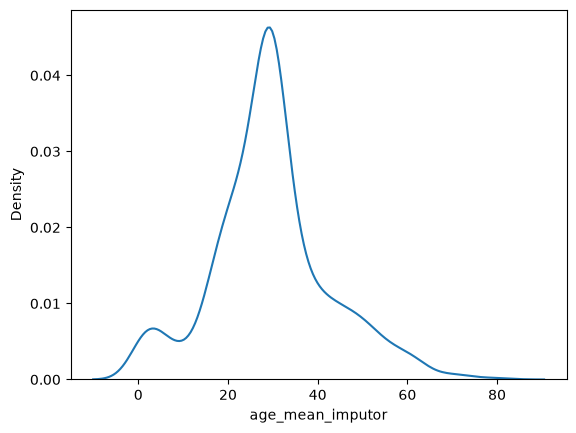

In [135]:
sns.kdeplot(data=X_train, x='age_mean_imputor')

<Axes: xlabel='age_median_imputor', ylabel='Density'>

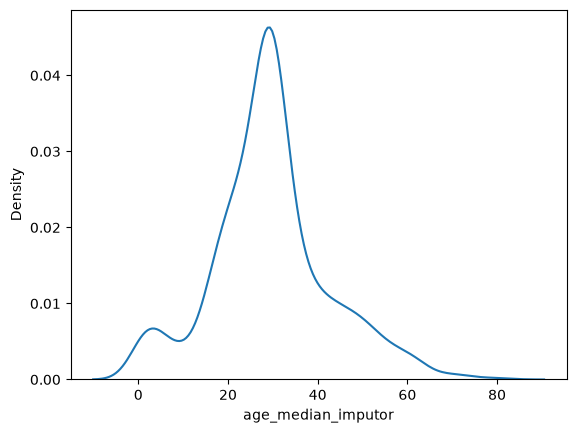

In [136]:
sns.kdeplot(data=X_train, x='age_median_imputor')

# Simple Imputor

In [137]:
from sklearn.impute import SimpleImputer


In [138]:
age_imputer = SimpleImputer(missing_values=np.nan, strategy='mean')

age_imputer.fit(X_train[['Age']])

X_train['Age'] = age_imputer.transform(X_train[['Age']])

In [139]:
X_train.isnull().sum()
X_train.drop(['age_mean_imputor','age_median_imputor'],axis=1,inplace=True)

X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
331,first,male,45.500000,0,0,28.5000,C124,S
733,second,male,23.000000,0,0,13.0000,NaN,S
382,third,male,32.000000,0,0,7.9250,NaN,S
704,third,male,26.000000,1,0,7.8542,NaN,S
813,third,female,6.000000,4,2,31.2750,NaN,S
...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,NaN,S
270,first,male,29.498846,0,0,31.0000,NaN,S
860,third,male,41.000000,2,0,14.1083,NaN,S
435,first,female,14.000000,1,2,120.0000,B96 B98,S


In [140]:
X_test['Age'] = age_imputer.transform(X_test[['Age']])

X_test.isnull().sum()

Pclass                  0
Sex                     0
Age                     0
SibSp                   0
Parch                   0
Fare                    0
Cabin                 134
Embarked                0
age_mean_imputor      179
age_median_imputor    179
dtype: int64

In [141]:
X_test.drop(['age_mean_imputor','age_median_imputor'],axis=1,inplace=True)

X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
709,third,male,29.498846,1,1,15.2458,NaN,C
439,second,male,31.000000,0,0,10.5000,NaN,S
840,third,male,20.000000,0,0,7.9250,NaN,S
720,second,female,6.000000,0,1,33.0000,NaN,S
39,third,female,14.000000,1,0,11.2417,NaN,C
...,...,...,...,...,...,...,...,...
433,third,male,17.000000,0,0,7.1250,NaN,S
773,third,male,29.498846,0,0,7.2250,NaN,C
25,third,female,38.000000,1,5,31.3875,NaN,S
84,second,female,17.000000,0,0,10.5000,NaN,S


In [142]:
embarked_imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

embarked_imputer.fit(X_train[['Embarked']])

# transform both train and test data

X_train['Embarked'] =embarked_imputer.transform(X_train[['Embarked']]).ravel()



In [143]:
X_train.isnull().sum()
X_test.isnull().sum()

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       134
Embarked      0
dtype: int64

# Categorical Value Imputation with Missing string and Indicator


<Axes: xlabel='Cabin', ylabel='count'>

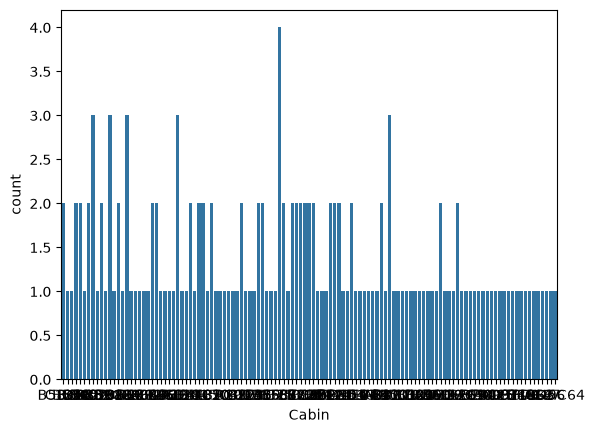

In [144]:
sns.countplot(data=X_train,x=X_train['Cabin'])

In [145]:
cabin_imputer = SimpleImputer(missing_values=np.nan, strategy='constant',fill_value='Missing', add_indicator=True)

cabin_imputer.fit(X_train[['Cabin']])

# transform both train and test data

X_train[['Cabin','cabin_missing_indicator']] = cabin_imputer.transform(X_train[['Cabin']])
X_test[['Cabin','cabin_missing_indicator']] = cabin_imputer.transform(X_test[['Cabin']])


In [146]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator
331,first,male,45.500000,0,0,28.5000,C124,S,False
733,second,male,23.000000,0,0,13.0000,Missing,S,True
382,third,male,32.000000,0,0,7.9250,Missing,S,True
704,third,male,26.000000,1,0,7.8542,Missing,S,True
813,third,female,6.000000,4,2,31.2750,Missing,S,True
...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True
270,first,male,29.498846,0,0,31.0000,Missing,S,True
860,third,male,41.000000,2,0,14.1083,Missing,S,True
435,first,female,14.000000,1,2,120.0000,B96 B98,S,False


In [147]:
X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator
709,third,male,29.498846,1,1,15.2458,Missing,C,True
439,second,male,31.000000,0,0,10.5000,Missing,S,True
840,third,male,20.000000,0,0,7.9250,Missing,S,True
720,second,female,6.000000,0,1,33.0000,Missing,S,True
39,third,female,14.000000,1,0,11.2417,Missing,C,True
...,...,...,...,...,...,...,...,...,...
433,third,male,17.000000,0,0,7.1250,Missing,S,True
773,third,male,29.498846,0,0,7.2250,Missing,C,True
25,third,female,38.000000,1,5,31.3875,Missing,S,True
84,second,female,17.000000,0,0,10.5000,Missing,S,True


In [148]:
X_train.isnull().sum()

Pclass                     0
Sex                        0
Age                        0
SibSp                      0
Parch                      0
Fare                       0
Cabin                      0
Embarked                   0
cabin_missing_indicator    0
dtype: int64

In [149]:
X_test.isnull().sum()

Pclass                     0
Sex                        0
Age                        0
SibSp                      0
Parch                      0
Fare                       0
Cabin                      0
Embarked                   0
cabin_missing_indicator    0
dtype: int64

# Outlier Detection

Using Z-Score

In [150]:
mean_of_age = X_train['Age'].mean()
std_of_age = X_train['Age'].std()

X_train['zscore_Age'] = (X_train['Age'] - mean_of_age) / std_of_age

X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,zscore_Age
331,first,male,45.500000,0,0,28.5000,C124,S,False,1.231398e+00
733,second,male,23.000000,0,0,13.0000,Missing,S,True,-5.001304e-01
382,third,male,32.000000,0,0,7.9250,Missing,S,True,1.924808e-01
704,third,male,26.000000,1,0,7.8542,Missing,S,True,-2.692600e-01
813,third,female,6.000000,4,2,31.2750,Missing,S,True,-1.808396e+00
...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True,-6.540440e-01
270,first,male,29.498846,0,0,31.0000,Missing,S,True,2.734055e-16
860,third,male,41.000000,2,0,14.1083,Missing,S,True,8.850920e-01
435,first,female,14.000000,1,2,120.0000,B96 B98,S,False,-1.192742e+00


In [151]:
outliers_age =X_train[abs(X_train['zscore_Age']) > 3]

print(len(outliers_age))

display(outliers_age)

5


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,zscore_Age
116,third,male,70.5,0,0,7.750,Missing,Q,True,3.155317
745,first,male,70.0,1,1,71.000,B22,S,False,3.116839
630,first,male,80.0,0,0,30.000,A23,S,False,3.886407
851,third,male,74.0,0,0,7.775,Missing,S,True,3.424666
672,second,male,70.0,0,0,10.500,Missing,S,True,3.116839


In [152]:
mean_of_fare = X_train['Fare'].mean()
std_of_fare = X_train['Fare'].std()

X_train['zscore_Fare'] = (X_train['Fare'] - mean_of_fare) / std_of_fare

X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,zscore_Age,zscore_Fare
331,first,male,45.500000,0,0,28.5000,C124,S,False,1.231398e+00,-0.078628
733,second,male,23.000000,0,0,13.0000,Missing,S,True,-5.001304e-01,-0.376880
382,third,male,32.000000,0,0,7.9250,Missing,S,True,1.924808e-01,-0.474533
704,third,male,26.000000,1,0,7.8542,Missing,S,True,-2.692600e-01,-0.475896
813,third,female,6.000000,4,2,31.2750,Missing,S,True,-1.808396e+00,-0.025232
...,...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True,-6.540440e-01,-0.479825
270,first,male,29.498846,0,0,31.0000,Missing,S,True,2.734055e-16,-0.030523
860,third,male,41.000000,2,0,14.1083,Missing,S,True,8.850920e-01,-0.355554
435,first,female,14.000000,1,2,120.0000,B96 B98,S,False,-1.192742e+00,1.682019


In [153]:
outliers_fare =X_train[abs(X_train['zscore_Fare']) > 3]

print(len(outliers_fare))

display(outliers_fare)

17


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,zscore_Age,zscore_Fare
118,first,male,24.000000,0,1,247.5208,B58 B60,C,False,-4.231736e-01,4.135780
716,first,female,38.000000,0,0,227.5250,C45,C,False,6.542216e-01,3.751020
377,first,male,27.000000,0,2,211.5000,C82,C,False,-1.923032e-01,3.442666
742,first,female,21.000000,2,2,262.3750,B57 B59 B63 B66,C,False,-6.540440e-01,4.421605
380,first,female,42.000000,0,0,227.5250,Missing,C,True,9.620488e-01,3.751020
779,first,female,43.000000,0,1,211.3375,B3,S,False,1.039006e+00,3.439539
730,first,female,29.000000,0,0,211.3375,B5,S,False,-3.838960e-02,3.439539
88,first,female,23.000000,3,2,263.0000,C23 C25 C27,S,False,-5.001304e-01,4.433631
341,first,female,24.000000,3,2,263.0000,C23 C25 C27,S,False,-4.231736e-01,4.433631
557,first,male,29.498846,0,0,227.5250,Missing,C,True,2.734055e-16,3.751020


# Outliers with IQR

In [154]:
# age 

age_Q1 = X_train['Age'].quantile(0.25)
age_Q3 = X_train['Age'].quantile(0.75)

age_IQR = age_Q3 - age_Q1 

age_minimum = age_Q1 - 1.5 * age_IQR
age_maximum = age_Q3 + 1.5 * age_IQR

print(age_minimum, age_maximum)


2.5 54.5


In [155]:
age_outlier_IQR = X_train[(X_train['Age'] < age_minimum) | (X_train['Age'] > age_maximum)]

print(len(age_outlier_IQR))
display(age_outlier_IQR)

54


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,zscore_Age,zscore_Fare
326,third,male,61.00,0,0,6.2375,Missing,S,True,2.424228,-0.507004
483,third,female,63.00,0,0,9.5875,Missing,S,True,2.578141,-0.442543
7,third,male,2.00,3,1,21.0750,Missing,S,True,-2.116223,-0.221500
305,first,male,0.92,1,2,151.5500,C22 C26,S,False,-2.199336,2.289105
829,first,female,62.00,0,0,80.0000,B28,S,False,2.501185,0.912337
626,second,male,57.00,0,0,12.3500,Missing,Q,True,2.116401,-0.389387
456,first,male,65.00,0,0,26.5500,E38,S,False,2.732055,-0.116150
172,third,female,1.00,1,1,11.1333,Missing,S,True,-2.193180,-0.412799
164,third,male,1.00,4,1,39.6875,Missing,S,True,-2.193180,0.136642
381,third,female,1.00,0,2,15.7417,Missing,C,True,-2.193180,-0.324124


In [156]:
# fare
fare_Q1 = X_train['Fare'].quantile(0.25)
fare_Q3 = X_train['Fare'].quantile(0.75)

fare_IQR = fare_Q3 - fare_Q1 

fare_minimum = max(0,fare_Q1 - 1.5 * fare_IQR)
fare_maximum = fare_Q3 + 1.5 * fare_IQR

print(fare_minimum, fare_maximum)

0 64.3625


In [157]:
fare_outlier_IQR = X_train[(X_train['Fare'] < fare_minimum) | (X_train['Fare'] > fare_maximum)]

print(len(fare_outlier_IQR))
display(fare_outlier_IQR)

96


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,zscore_Age,zscore_Fare
118,first,male,24.0,0,1,247.5208,B58 B60,C,False,-0.423174,4.135780
486,first,female,35.0,1,0,90.0000,C93,S,False,0.423351,1.104757
716,first,female,38.0,0,0,227.5250,C45,C,False,0.654222,3.751020
390,first,male,36.0,1,2,120.0000,B96 B98,S,False,0.500308,1.682019
377,first,male,27.0,0,2,211.5000,C82,C,False,-0.192303,3.442666
...,...,...,...,...,...,...,...,...,...,...,...
681,first,male,27.0,0,0,76.7292,D49,C,False,-0.192303,0.849400
385,second,male,18.0,0,0,73.5000,Missing,S,True,-0.884914,0.787264
700,first,female,18.0,1,0,227.5250,C62 C64,C,False,-0.884914,3.751020
435,first,female,14.0,1,2,120.0000,B96 B98,S,False,-1.192742,1.682019


In [158]:
# z score outlier detection is better for age outliers

X_train =X_train[abs(X_train['zscore_Age']) <= 3]

X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,zscore_Age,zscore_Fare
331,first,male,45.500000,0,0,28.5000,C124,S,False,1.231398e+00,-0.078628
733,second,male,23.000000,0,0,13.0000,Missing,S,True,-5.001304e-01,-0.376880
382,third,male,32.000000,0,0,7.9250,Missing,S,True,1.924808e-01,-0.474533
704,third,male,26.000000,1,0,7.8542,Missing,S,True,-2.692600e-01,-0.475896
813,third,female,6.000000,4,2,31.2750,Missing,S,True,-1.808396e+00,-0.025232
...,...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True,-6.540440e-01,-0.479825
270,first,male,29.498846,0,0,31.0000,Missing,S,True,2.734055e-16,-0.030523
860,third,male,41.000000,2,0,14.1083,Missing,S,True,8.850920e-01,-0.355554
435,first,female,14.000000,1,2,120.0000,B96 B98,S,False,-1.192742e+00,1.682019


In [159]:
minimum_zscore_fare =X_train[abs(X_train['zscore_Fare']) <= 3]['Fare'].min()

print(minimum_zscore_fare) 

0.0


In [160]:
X_train['Fare'] = X_train['Fare'].clip(fare_minimum, fare_maximum)

X_train['Fare'].max()

np.float64(64.3625)

#  Ordinal encoding

In [161]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,zscore_Age,zscore_Fare
331,first,male,45.500000,0,0,28.5000,C124,S,False,1.231398e+00,-0.078628
733,second,male,23.000000,0,0,13.0000,Missing,S,True,-5.001304e-01,-0.376880
382,third,male,32.000000,0,0,7.9250,Missing,S,True,1.924808e-01,-0.474533
704,third,male,26.000000,1,0,7.8542,Missing,S,True,-2.692600e-01,-0.475896
813,third,female,6.000000,4,2,31.2750,Missing,S,True,-1.808396e+00,-0.025232
...,...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True,-6.540440e-01,-0.479825
270,first,male,29.498846,0,0,31.0000,Missing,S,True,2.734055e-16,-0.030523
860,third,male,41.000000,2,0,14.1083,Missing,S,True,8.850920e-01,-0.355554
435,first,female,14.000000,1,2,64.3625,B96 B98,S,False,-1.192742e+00,1.682019


In [162]:
X_train.drop([ 'zscore_Age','zscore_Fare'  ],axis=1,inplace=True)

X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator
331,first,male,45.500000,0,0,28.5000,C124,S,False
733,second,male,23.000000,0,0,13.0000,Missing,S,True
382,third,male,32.000000,0,0,7.9250,Missing,S,True
704,third,male,26.000000,1,0,7.8542,Missing,S,True
813,third,female,6.000000,4,2,31.2750,Missing,S,True
...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True
270,first,male,29.498846,0,0,31.0000,Missing,S,True
860,third,male,41.000000,2,0,14.1083,Missing,S,True
435,first,female,14.000000,1,2,64.3625,B96 B98,S,False


In [163]:
from sklearn.preprocessing import OrdinalEncoder

pclass_encoder = OrdinalEncoder(categories=[['third', 'second', 'first']])


pclass_encoder.fit(X_train[['Pclass']])

#transform

X_train['Pclass_encoded'] = pclass_encoder.transform(X_train[['Pclass']]).ravel()
X_test['Pclass_encoded'] = pclass_encoder.transform(X_test[['Pclass']]).ravel()


X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,Pclass_encoded
331,first,male,45.500000,0,0,28.5000,C124,S,False,2.0
733,second,male,23.000000,0,0,13.0000,Missing,S,True,1.0
382,third,male,32.000000,0,0,7.9250,Missing,S,True,0.0
704,third,male,26.000000,1,0,7.8542,Missing,S,True,0.0
813,third,female,6.000000,4,2,31.2750,Missing,S,True,0.0
...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True,0.0
270,first,male,29.498846,0,0,31.0000,Missing,S,True,2.0
860,third,male,41.000000,2,0,14.1083,Missing,S,True,0.0
435,first,female,14.000000,1,2,64.3625,B96 B98,S,False,2.0


In [164]:
X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,Pclass_encoded
709,third,male,29.498846,1,1,15.2458,Missing,C,True,0.0
439,second,male,31.000000,0,0,10.5000,Missing,S,True,1.0
840,third,male,20.000000,0,0,7.9250,Missing,S,True,0.0
720,second,female,6.000000,0,1,33.0000,Missing,S,True,1.0
39,third,female,14.000000,1,0,11.2417,Missing,C,True,0.0
...,...,...,...,...,...,...,...,...,...,...
433,third,male,17.000000,0,0,7.1250,Missing,S,True,0.0
773,third,male,29.498846,0,0,7.2250,Missing,C,True,0.0
25,third,female,38.000000,1,5,31.3875,Missing,S,True,0.0
84,second,female,17.000000,0,0,10.5000,Missing,S,True,1.0


In [165]:
X_test.drop(['Pclass_encoded'],axis=1,inplace=True)

X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator
709,third,male,29.498846,1,1,15.2458,Missing,C,True
439,second,male,31.000000,0,0,10.5000,Missing,S,True
840,third,male,20.000000,0,0,7.9250,Missing,S,True
720,second,female,6.000000,0,1,33.0000,Missing,S,True
39,third,female,14.000000,1,0,11.2417,Missing,C,True
...,...,...,...,...,...,...,...,...,...
433,third,male,17.000000,0,0,7.1250,Missing,S,True
773,third,male,29.498846,0,0,7.2250,Missing,C,True
25,third,female,38.000000,1,5,31.3875,Missing,S,True
84,second,female,17.000000,0,0,10.5000,Missing,S,True


In [166]:
X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator
709,third,male,29.498846,1,1,15.2458,Missing,C,True
439,second,male,31.000000,0,0,10.5000,Missing,S,True
840,third,male,20.000000,0,0,7.9250,Missing,S,True
720,second,female,6.000000,0,1,33.0000,Missing,S,True
39,third,female,14.000000,1,0,11.2417,Missing,C,True
...,...,...,...,...,...,...,...,...,...
433,third,male,17.000000,0,0,7.1250,Missing,S,True
773,third,male,29.498846,0,0,7.2250,Missing,C,True
25,third,female,38.000000,1,5,31.3875,Missing,S,True
84,second,female,17.000000,0,0,10.5000,Missing,S,True


# Nominal Value Encoding

# One hot Encoding

In [167]:
from sklearn.preprocessing import OneHotEncoder

sex_ohe = OneHotEncoder(sparse_output=False).set_output(transform='pandas')

sex_ohe.fit(X_train[['Sex']])


encoded_df = sex_ohe.transform(X_train[['Sex']])


 
X_train = pd.concat([X_train, encoded_df], axis=1)

X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,Pclass_encoded,Sex_female,Sex_male
331,first,male,45.500000,0,0,28.5000,C124,S,False,2.0,0.0,1.0
733,second,male,23.000000,0,0,13.0000,Missing,S,True,1.0,0.0,1.0
382,third,male,32.000000,0,0,7.9250,Missing,S,True,0.0,0.0,1.0
704,third,male,26.000000,1,0,7.8542,Missing,S,True,0.0,0.0,1.0
813,third,female,6.000000,4,2,31.2750,Missing,S,True,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True,0.0,1.0,0.0
270,first,male,29.498846,0,0,31.0000,Missing,S,True,2.0,0.0,1.0
860,third,male,41.000000,2,0,14.1083,Missing,S,True,0.0,0.0,1.0
435,first,female,14.000000,1,2,64.3625,B96 B98,S,False,2.0,1.0,0.0


In [168]:
embarked_ohe = OneHotEncoder(sparse_output=False).set_output(transform='pandas')

embarked_ohe.fit(X_train[['Embarked']])


encoded_df = embarked_ohe.transform(X_train[['Embarked']])

X_train = pd.concat([X_train, encoded_df], axis=1)

X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,Pclass_encoded,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
331,first,male,45.500000,0,0,28.5000,C124,S,False,2.0,0.0,1.0,0.0,0.0,1.0
733,second,male,23.000000,0,0,13.0000,Missing,S,True,1.0,0.0,1.0,0.0,0.0,1.0
382,third,male,32.000000,0,0,7.9250,Missing,S,True,0.0,0.0,1.0,0.0,0.0,1.0
704,third,male,26.000000,1,0,7.8542,Missing,S,True,0.0,0.0,1.0,0.0,0.0,1.0
813,third,female,6.000000,4,2,31.2750,Missing,S,True,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True,0.0,1.0,0.0,0.0,0.0,1.0
270,first,male,29.498846,0,0,31.0000,Missing,S,True,2.0,0.0,1.0,0.0,0.0,1.0
860,third,male,41.000000,2,0,14.1083,Missing,S,True,0.0,0.0,1.0,0.0,0.0,1.0
435,first,female,14.000000,1,2,64.3625,B96 B98,S,False,2.0,1.0,0.0,0.0,0.0,1.0


In [169]:
encoded_df = embarked_ohe.transform(X_test[['Embarked']])

X_test = pd.concat([X_test, encoded_df], axis=1)

In [170]:
X_train.drop(['Pclass', 'Sex', 'Embarked'], axis=1, inplace=True)

X_train

,Age,SibSp,Parch,Fare,Cabin,cabin_missing_indicator,Pclass_encoded,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
331,45.500000,0,0,28.5000,C124,False,2.0,0.0,1.0,0.0,0.0,1.0
733,23.000000,0,0,13.0000,Missing,True,1.0,0.0,1.0,0.0,0.0,1.0
382,32.000000,0,0,7.9250,Missing,True,0.0,0.0,1.0,0.0,0.0,1.0
704,26.000000,1,0,7.8542,Missing,True,0.0,0.0,1.0,0.0,0.0,1.0
813,6.000000,4,2,31.2750,Missing,True,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
106,21.000000,0,0,7.6500,Missing,True,0.0,1.0,0.0,0.0,0.0,1.0
270,29.498846,0,0,31.0000,Missing,True,2.0,0.0,1.0,0.0,0.0,1.0
860,41.000000,2,0,14.1083,Missing,True,0.0,0.0,1.0,0.0,0.0,1.0
435,14.000000,1,2,64.3625,B96 B98,False,2.0,1.0,0.0,0.0,0.0,1.0


In [171]:
X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,Embarked_C,Embarked_Q,Embarked_S
709,third,male,29.498846,1,1,15.2458,Missing,C,True,1.0,0.0,0.0
439,second,male,31.000000,0,0,10.5000,Missing,S,True,0.0,0.0,1.0
840,third,male,20.000000,0,0,7.9250,Missing,S,True,0.0,0.0,1.0
720,second,female,6.000000,0,1,33.0000,Missing,S,True,0.0,0.0,1.0
39,third,female,14.000000,1,0,11.2417,Missing,C,True,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
433,third,male,17.000000,0,0,7.1250,Missing,S,True,0.0,0.0,1.0
773,third,male,29.498846,0,0,7.2250,Missing,C,True,1.0,0.0,0.0
25,third,female,38.000000,1,5,31.3875,Missing,S,True,0.0,0.0,1.0
84,second,female,17.000000,0,0,10.5000,Missing,S,True,0.0,0.0,1.0


In [172]:
X_test.drop(['Pclass', 'Sex', 'Embarked'], axis=1, inplace=True)

In [173]:
X_test

,Age,SibSp,Parch,Fare,Cabin,cabin_missing_indicator,Embarked_C,Embarked_Q,Embarked_S
709,29.498846,1,1,15.2458,Missing,True,1.0,0.0,0.0
439,31.000000,0,0,10.5000,Missing,True,0.0,0.0,1.0
840,20.000000,0,0,7.9250,Missing,True,0.0,0.0,1.0
720,6.000000,0,1,33.0000,Missing,True,0.0,0.0,1.0
39,14.000000,1,0,11.2417,Missing,True,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
433,17.000000,0,0,7.1250,Missing,True,0.0,0.0,1.0
773,29.498846,0,0,7.2250,Missing,True,1.0,0.0,0.0
25,38.000000,1,5,31.3875,Missing,True,0.0,0.0,1.0
84,17.000000,0,0,10.5000,Missing,True,0.0,0.0,1.0


# Encoding the Cabin features

In [174]:
X_train['Cabin'].value_counts()

Cabin
Missing        550
C23 C25 C27      4
B96 B98          3
C22 C26          3
F2               3
              ... 
A14              1
D49              1
C87              1
D56              1
C62 C64          1
Name: count, Length: 117, dtype: int64

In [175]:
X_train['Cabin_Deck'] = X_train['Cabin'].astype(str).str[0]

X_train 

,Age,SibSp,Parch,Fare,Cabin,cabin_missing_indicator,Pclass_encoded,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Cabin_Deck
331,45.500000,0,0,28.5000,C124,False,2.0,0.0,1.0,0.0,0.0,1.0,C
733,23.000000,0,0,13.0000,Missing,True,1.0,0.0,1.0,0.0,0.0,1.0,M
382,32.000000,0,0,7.9250,Missing,True,0.0,0.0,1.0,0.0,0.0,1.0,M
704,26.000000,1,0,7.8542,Missing,True,0.0,0.0,1.0,0.0,0.0,1.0,M
813,6.000000,4,2,31.2750,Missing,True,0.0,1.0,0.0,0.0,0.0,1.0,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,21.000000,0,0,7.6500,Missing,True,0.0,1.0,0.0,0.0,0.0,1.0,M
270,29.498846,0,0,31.0000,Missing,True,2.0,0.0,1.0,0.0,0.0,1.0,M
860,41.000000,2,0,14.1083,Missing,True,0.0,0.0,1.0,0.0,0.0,1.0,M
435,14.000000,1,2,64.3625,B96 B98,False,2.0,1.0,0.0,0.0,0.0,1.0,B


In [176]:
X_train['Cabin_Deck'].value_counts()

Cabin_Deck
M    550
C     52
B     37
E     24
D     19
F     12
A      9
G      3
T      1
Name: count, dtype: int64

In [177]:
X_test['Cabin_Deck'] = X_test['Cabin'].astype(str).str[0]

In [178]:
cabin_deck_ohe = OneHotEncoder(sparse_output=False, drop='first').set_output(transform='pandas')

cabin_deck_ohe.fit(X_train[['Cabin_Deck']])


encoded_df = cabin_deck_ohe.transform(X_train[['Cabin_Deck']])

X_train = pd.concat([X_train, encoded_df], axis=1)

X_train

,Age,SibSp,Parch,Fare,Cabin,cabin_missing_indicator,Pclass_encoded,Sex_female,Sex_male,Embarked_C,...,Embarked_S,Cabin_Deck,Cabin_Deck_B,Cabin_Deck_C,Cabin_Deck_D,Cabin_Deck_E,Cabin_Deck_F,Cabin_Deck_G,Cabin_Deck_M,Cabin_Deck_T
331,45.500000,0,0,28.5000,C124,False,2.0,0.0,1.0,0.0,...,1.0,C,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
733,23.000000,0,0,13.0000,Missing,True,1.0,0.0,1.0,0.0,...,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
382,32.000000,0,0,7.9250,Missing,True,0.0,0.0,1.0,0.0,...,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
704,26.000000,1,0,7.8542,Missing,True,0.0,0.0,1.0,0.0,...,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
813,6.000000,4,2,31.2750,Missing,True,0.0,1.0,0.0,0.0,...,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,21.000000,0,0,7.6500,Missing,True,0.0,1.0,0.0,0.0,...,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
270,29.498846,0,0,31.0000,Missing,True,2.0,0.0,1.0,0.0,...,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
860,41.000000,2,0,14.1083,Missing,True,0.0,0.0,1.0,0.0,...,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
435,14.000000,1,2,64.3625,B96 B98,False,2.0,1.0,0.0,0.0,...,1.0,B,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [179]:
encoded_df = cabin_deck_ohe.transform(X_test[['Cabin_Deck']])

X_test = pd.concat([X_test, encoded_df], axis=1)

X_test

,Age,SibSp,Parch,Fare,Cabin,cabin_missing_indicator,Embarked_C,Embarked_Q,Embarked_S,Cabin_Deck,Cabin_Deck_B,Cabin_Deck_C,Cabin_Deck_D,Cabin_Deck_E,Cabin_Deck_F,Cabin_Deck_G,Cabin_Deck_M,Cabin_Deck_T
709,29.498846,1,1,15.2458,Missing,True,1.0,0.0,0.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
439,31.000000,0,0,10.5000,Missing,True,0.0,0.0,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
840,20.000000,0,0,7.9250,Missing,True,0.0,0.0,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
720,6.000000,0,1,33.0000,Missing,True,0.0,0.0,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
39,14.000000,1,0,11.2417,Missing,True,1.0,0.0,0.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433,17.000000,0,0,7.1250,Missing,True,0.0,0.0,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
773,29.498846,0,0,7.2250,Missing,True,1.0,0.0,0.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
25,38.000000,1,5,31.3875,Missing,True,0.0,0.0,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
84,17.000000,0,0,10.5000,Missing,True,0.0,0.0,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [180]:
X_train.drop(['Cabin_Deck'], axis=1, inplace=True)
X_test.drop(['Cabin_Deck'], axis=1, inplace=True)

In [181]:
X_train

,Age,SibSp,Parch,Fare,Cabin,cabin_missing_indicator,Pclass_encoded,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Cabin_Deck_B,Cabin_Deck_C,Cabin_Deck_D,Cabin_Deck_E,Cabin_Deck_F,Cabin_Deck_G,Cabin_Deck_M,Cabin_Deck_T
331,45.500000,0,0,28.5000,C124,False,2.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
733,23.000000,0,0,13.0000,Missing,True,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
382,32.000000,0,0,7.9250,Missing,True,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
704,26.000000,1,0,7.8542,Missing,True,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
813,6.000000,4,2,31.2750,Missing,True,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,21.000000,0,0,7.6500,Missing,True,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
270,29.498846,0,0,31.0000,Missing,True,2.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
860,41.000000,2,0,14.1083,Missing,True,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
435,14.000000,1,2,64.3625,B96 B98,False,2.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Label encoding


In [183]:
y_train

331     no
733     no
382     no
704     no
813     no
      ... 
106    yes
270     no
860     no
435    yes
102     no
Name: Survived, Length: 712, dtype: str

In [187]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

#fit 
le.fit(y_train)

#transform

y_train_array = le.transform(y_train)
y_test_array = le.transform(y_test)


In [188]:
y_train = pd.Series(y_train_array, index =y_train.index, name=y_train.name)
y_test = pd.Series(y_test_array, index =y_test.index, name=y_test.name)

In [189]:
y_train

331    0
733    0
382    0
704    0
813    0
      ..
106    1
270    0
860    0
435    1
102    0
Name: Survived, Length: 712, dtype: int64

# Standard Scaling

<Axes: xlabel='Age', ylabel='Density'>

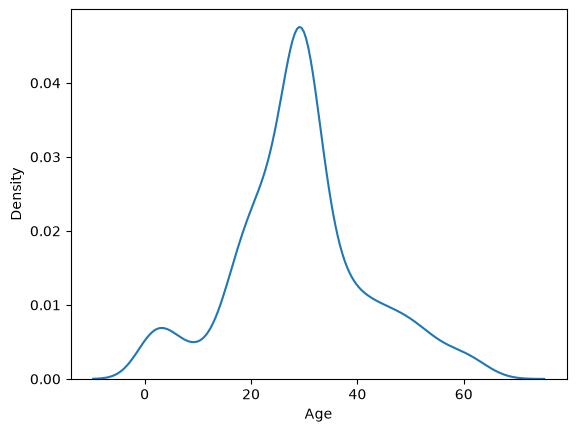

In [190]:
sns.kdeplot(data=X_train, x = 'Age')

In [191]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

ss.fit(X_train[['Age']])

X_train['Age'] = ss.transform(X_train[['Age']]).ravel()
X_test['Age'] = ss.transform(X_test[['Age']]).ravel() 


In [192]:
X_train.sample(5)

,Age,SibSp,Parch,Fare,Cabin,cabin_missing_indicator,Pclass_encoded,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Cabin_Deck_B,Cabin_Deck_C,Cabin_Deck_D,Cabin_Deck_E,Cabin_Deck_F,Cabin_Deck_G,Cabin_Deck_M,Cabin_Deck_T
654,-0.895248,0,0,6.75,Missing,True,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
747,0.064640,0,0,13.00,Missing,True,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
289,-0.575285,0,0,7.75,Missing,True,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
491,-0.655276,0,0,7.25,Missing,True,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
21,0.384602,0,0,13.00,D56,False,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [194]:
round(X_train['Age'].mean(),5)

np.float64(0.0)

In [197]:
round(X_train['Age'].std(),5)

np.float64(1.00071)

<Axes: xlabel='Age', ylabel='Density'>

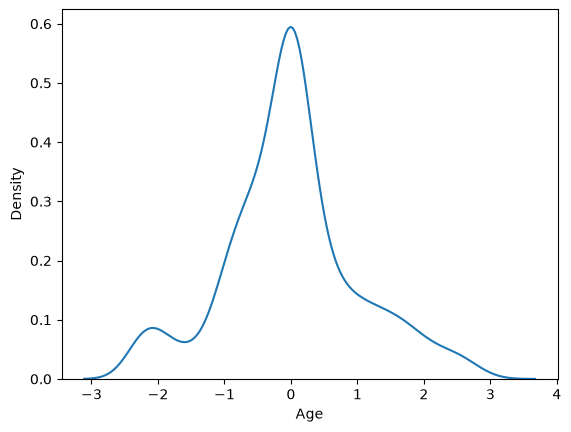

In [198]:
sns.kdeplot(data=X_train, x = 'Age')

# Min Max Scaling

<Axes: xlabel='Fare', ylabel='Density'>

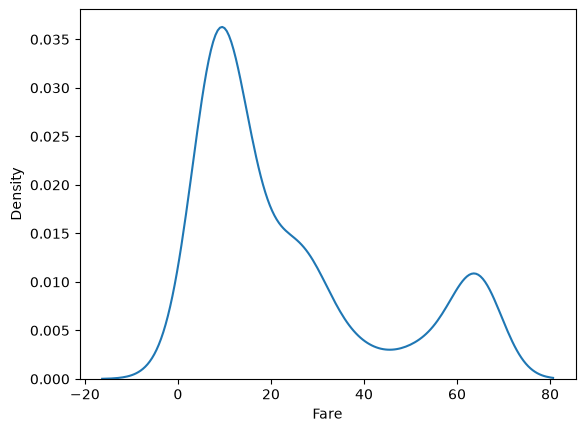

In [199]:
sns.kdeplot(data=X_train, x='Fare')

In [200]:
from sklearn.preprocessing import MinMaxScaler

mms = MinMaxScaler()

mms.fit(X_train[['Fare']])

X_train['Fare']  = mms.transform(X_train[['Fare']]).ravel()
X_test['Fare']  = mms.transform(X_test[['Fare']]).ravel()



In [201]:
X_train['Fare'].describe()

count    707.000000
mean       0.368633
std        0.313162
min        0.000000
25%        0.123131
50%        0.224575
75%        0.473878
max        1.000000
Name: Fare, dtype: float64

<Axes: xlabel='Fare', ylabel='Density'>

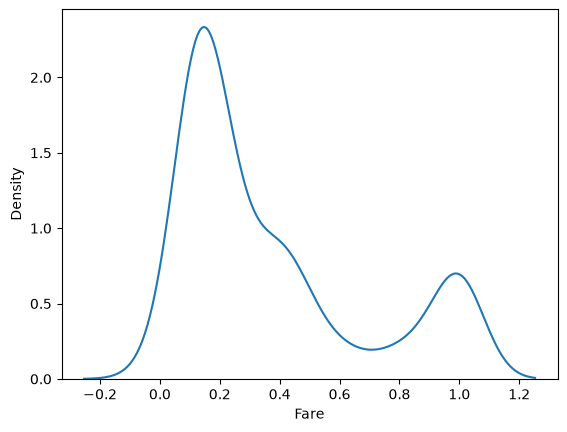

In [202]:
sns.kdeplot(data=X_train, x='Fare')